In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from scipy.stats import ks_2samp
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from catboost import CatBoostClassifier
from scipy.stats import ks_2samp
import h2o
from h2o.automl import H2OAutoML
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import optuna


file_path = os.path.join('..', 'Data', 'processed', 'Data.pkl')
Data = pd.read_pickle(file_path)

In [2]:
X = Data.drop(columns=['target'])
y = Data['target']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [9]:

from lightgbm import LGBMClassifier

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 31, 128),
        'max_depth': trial.suggest_int('max_depth', -1, 15),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'random_state': 42
    }

    # Crear el modelo
    model = LGBMClassifier(**params)

    # Configurar callbacks para early stopping
    callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)]

    # Entrenar el modelo
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=callbacks,
        )

    # Evaluar el modelo
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_pred_proba)

# Crear el estudio de optimización
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print("Mejores parámetros:", study.best_params)
print("Mejor ROC AUC en validación:", study.best_value)

[I 2025-03-27 18:19:16,336] A new study created in memory with name: no-name-8d73b755-0cb7-40fd-8cd5-8244fb2d1e8f


[LightGBM] [Info] Number of positive: 790, number of negative: 26499
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014988 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10582
[LightGBM] [Info] Number of data points in the train set: 27289, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.028949 -> initscore=-3.512829
[LightGBM] [Info] Start training from score -3.512829
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

[I 2025-03-27 18:19:20,918] Trial 0 finished with value: 0.6564431816168985 and parameters: {'learning_rate': 0.08170563556069514, 'num_leaves': 112, 'max_depth': 8, 'n_estimators': 199, 'subsample': 0.9355212871440366, 'colsample_bytree': 0.7224817689006593, 'reg_alpha': 0.03531281716715018, 'reg_lambda': 0.7752126608216928}. Best is trial 0 with value: 0.6564431816168985.


[LightGBM] [Info] Number of positive: 790, number of negative: 26499
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10582
[LightGBM] [Info] Number of data points in the train set: 27289, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.028949 -> initscore=-3.512829
[LightGBM] [Info] Start training from score -3.512829
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2025-03-27 18:19:23,437] Trial 1 finished with value: 0.6793136969901568 and parameters: {'learning_rate': 0.05940421257076519, 'num_leaves': 65, 'max_depth': 7, 'n_estimators': 572, 'subsample': 0.6645976967899483, 'colsample_bytree': 0.5949058842783603, 'reg_alpha': 0.2391866537598516, 'reg_lambda': 0.6758540786841452}. Best is trial 1 with value: 0.6793136969901568.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 790, number of negative: 26499
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.047629 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10582
[LightGBM] [Info] Number of data points in the train set: 27289, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.028949 -> initscore=-3.512829
[LightGBM] [Info] Start training from score -3.512829
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2025-03-27 18:23:28,800] Trial 98 finished with value: 0.6763191702847925 and parameters: {'learning_rate': 0.07460213207602799, 'num_leaves': 89, 'max_depth': 5, 'n_estimators': 621, 'subsample': 0.5596169242934097, 'colsample_bytree': 0.5778721653747649, 'reg_alpha': 0.31516247985494605, 'reg_lambda': 0.3614219171622239}. Best is trial 68 with value: 0.6849078563085634.


[LightGBM] [Info] Number of positive: 790, number of negative: 26499
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052755 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10582
[LightGBM] [Info] Number of data points in the train set: 27289, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.028949 -> initscore=-3.512829
[LightGBM] [Info] Start training from score -3.512829
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2025-03-27 18:23:32,076] Trial 99 finished with value: 0.6704093040799124 and parameters: {'learning_rate': 0.07167350214123537, 'num_leaves': 93, 'max_depth': 3, 'n_estimators': 549, 'subsample': 0.577481916065805, 'colsample_bytree': 0.6418507862747427, 'reg_alpha': 0.4724116470432108, 'reg_lambda': 0.8501215912016981}. Best is trial 68 with value: 0.6849078563085634.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


ROC AUC: 0.6785
Accuracy: 0.9711
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000


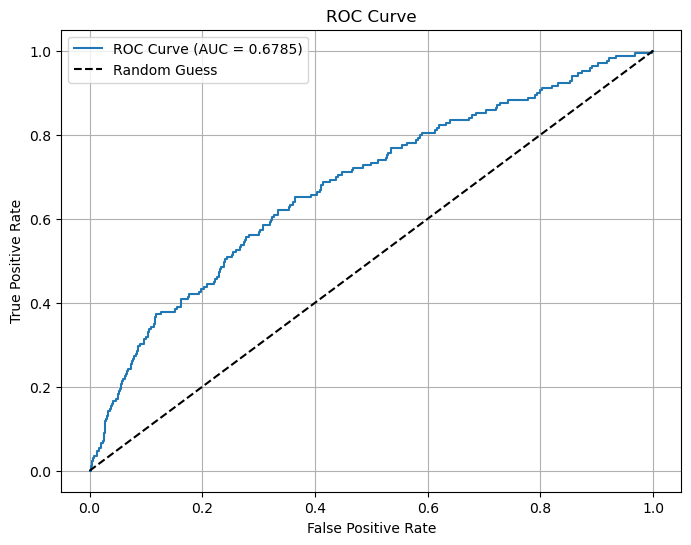

In [17]:
best_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.054302735201311195,
    'num_leaves': 100,
    'max_depth': 5,
    'n_estimators': 586,
    'subsample': 0.5810174624610054,
    'colsample_bytree': 0.6109487371656337,
    'reg_alpha': 0.9340148727680123,
    'reg_lambda': 0.3460746876883639,
    'random_state': 42,
    'verbosity': 0
}

model = LGBMClassifier(**best_params)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"ROC AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [3]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 5, 10],
    'n_estimators': [100, 200, 500]
}

# Crear el modelo base
lgb_estimator = lgb.LGBMClassifier(objective='binary', metric='auc', boosting_type='gbdt', random_state=42)

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=lgb_estimator,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Entrenar GridSearchCV
grid_search.fit(X_train, y_train)

# Mejores parámetros y rendimiento
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor ROC AUC en validación:", grid_search.best_score_)

# Usar el mejor modelo
best_lgb_model = grid_search.best_estimator_

# Evaluar en el conjunto de prueba
y_pred_proba_best_lgb = best_lgb_model.predict_proba(X_test)[:, 1]
y_pred_best_lgb = (y_pred_proba_best_lgb > 0.5).astype(int)

roc_auc_best_lgb = roc_auc_score(y_test, y_pred_proba_best_lgb)
accuracy_best_lgb = accuracy_score(y_test, y_pred_best_lgb)
ks_stat_best_lgb = ks_2samp(y_pred_proba_best_lgb[y_test == 1], y_pred_proba_best_lgb[y_test == 0]).statistic

print(f"LightGBM Optimizado - ROC AUC: {roc_auc_best_lgb:.4f}, Accuracy: {accuracy_best_lgb:.4f}, KS: {ks_stat_best_lgb:.4f}")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
[LightGBM] [Info] Number of positive: 790, number of negative: 26499
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10582
[LightGBM] [Info] Number of data points in the train set: 27289, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.028949 -> initscore=-3.512829
[LightGBM] [Info] Start training from score -3.512829
Mejores parámetros: {'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 200, 'num_leaves': 31}
Mejor ROC AUC en validación: 0.6335228064899118
LightGBM Optimizado - ROC AUC: 0.6669, Accuracy: 0.9711, KS: 0.2786


In [4]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val)

callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=True)]

model_lgb = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    num_boost_round=1000,
    callbacks=callbacks
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[32]	valid_0's auc: 0.641267


In [5]:
y_pred_proba = model_lgb.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)
ks_stat = ks_2samp(y_pred_proba[y_test == 1], y_pred_proba[y_test == 0]).statistic

print(f"ROC AUC: {roc_auc:.4f}, Accuracy: {accuracy:.4f}, KS: {ks_stat:.4f}")

ROC AUC: 0.6762, Accuracy: 0.9711, KS: 0.2876


-------------

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

y_train = y_train.values.ravel() if isinstance(y_train, pd.Series) else y_train.ravel()
y_val = y_val.values.ravel() if isinstance(y_val, pd.Series) else y_val.ravel()
y_test = y_test.values.ravel() if isinstance(y_test, pd.Series) else y_test.ravel()


unique_classes = np.unique(y_train)
print("Clases únicas en y_train:", unique_classes)
print("Tipo de datos en y_train:", y_train.dtype)

class_weights = compute_class_weight(
    'balanced', 
    classes=unique_classes,  
    y=y_train
)


class_weights_dict = {int(cls): weight for cls, weight in zip(unique_classes, class_weights)}
print("Pesos de las clases ajustados:", class_weights_dict)


model_nn = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),  
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])


model_nn.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='binary_crossentropy', 
    metrics=['AUC']
)

history = model_nn.fit(
    X_train_scaled, 
    y_train, 
    validation_data=(X_val_scaled, y_val), 
    epochs=50, 
    batch_size=32, 
    class_weight=class_weights_dict, 
    verbose=1
)

Clases únicas en y_train: [0. 1.]
Tipo de datos en y_train: float64
Pesos de las clases ajustados: {0: 0.5149062228763349, 1: 17.27151898734177}
Epoch 1/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - AUC: 0.5413 - loss: 0.7415 - val_AUC: 0.6335 - val_loss: 0.6955
Epoch 2/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.6276 - loss: 0.6801 - val_AUC: 0.6355 - val_loss: 0.6352
Epoch 3/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.6465 - loss: 0.6706 - val_AUC: 0.6566 - val_loss: 0.5885
Epoch 4/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.6840 - loss: 0.6320 - val_AUC: 0.6465 - val_loss: 0.6334
Epoch 5/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.6790 - loss: 0.6360 - val_AUC: 0.6480 - val_loss: 0.6109
Epoch 6/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.6892 - loss: 0.6352 - val_AUC: 0.6578 - val_loss: 0.6021
Epoch 7/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.7051 - loss: 0.6247 - val_AUC: 0.6394 - val_loss: 0.6311
Epoch 8/50
853/853 ━━━━━━━━━━

In [12]:
y_pred_proba_nn = model_nn.predict(X_test_scaled).flatten()
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

roc_auc_nn = roc_auc_score(y_test, y_pred_proba_nn)
accuracy_nn = accuracy_score(y_test, y_pred_nn)
ks_stat_nn = ks_2samp(y_pred_proba_nn[y_test == 1], y_pred_proba_nn[y_test == 0]).statistic

print(f"ROC AUC (NN): {roc_auc_nn:.4f}, Accuracy (NN): {accuracy_nn:.4f}, KS (NN): {ks_stat_nn:.4f}")

183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
ROC AUC (NN): 0.6321, Accuracy (NN): 0.7196, KS (NN): 0.2399


In [14]:
model_catboost = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,  
    depth=8,          
    loss_function='Logloss',
    eval_metric='AUC',
    auto_class_weights='Balanced',  
    verbose=100,
    random_state=42
)

model_catboost.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=100  
)

y_pred_proba_catboost = model_catboost.predict_proba(X_test)[:, 1]
y_pred_catboost = (y_pred_proba_catboost > 0.5).astype(int)

roc_auc_catboost = roc_auc_score(y_test, y_pred_proba_catboost)
accuracy_catboost = accuracy_score(y_test, y_pred_catboost)
ks_stat_catboost = ks_2samp(y_pred_proba_catboost[y_test == 1], y_pred_proba_catboost[y_test == 0]).statistic
precision_catboost = precision_score(y_test, y_pred_catboost)
recall_catboost = recall_score(y_test, y_pred_catboost)
f1_catboost = f1_score(y_test, y_pred_catboost)

print(f"CatBoost - ROC AUC: {roc_auc_catboost:.4f}, Accuracy: {accuracy_catboost:.4f}, KS: {ks_stat_catboost:.4f}")
print(f"CatBoost - Precision: {precision_catboost:.4f}, Recall: {recall_catboost:.4f}, F1: {f1_catboost:.4f}")


0:	test: 0.5561547	best: 0.5561547 (0)	total: 260ms	remaining: 4m 19s
100:	test: 0.6272023	best: 0.6308866 (37)	total: 7.14s	remaining: 1m 3s
200:	test: 0.6252142	best: 0.6362046 (115)	total: 11.8s	remaining: 46.7s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6362045989
bestIteration = 115

Shrink model to first 116 iterations.
CatBoost - ROC AUC: 0.6177, Accuracy: 0.8365, KS: 0.1863
CatBoost - Precision: 0.0523, Recall: 0.2722, F1: 0.0878


In [18]:
print("Tipo de X_train:", type(X_train))
print("Tipo de y_train:", type(y_train))
print("Tipo de X_val:", type(X_val))
print("Tipo de y_val:", type(y_val))
print("Tipo de X_test:", type(X_test))
print("Tipo de y_test:", type(y_test))

Tipo de X_train: <class 'pandas.core.frame.DataFrame'>
Tipo de y_train: <class 'pandas.core.series.Series'>
Tipo de X_val: <class 'pandas.core.frame.DataFrame'>
Tipo de y_val: <class 'pandas.core.series.Series'>
Tipo de X_test: <class 'pandas.core.frame.DataFrame'>
Tipo de y_test: <class 'pandas.core.series.Series'>


In [19]:
h2o.init()

y_train = pd.Series(y_train, name='target').astype('category')
y_val = pd.Series(y_val, name='target').astype('category')
y_test = pd.Series(y_test, name='target').astype('category')

train_h2o = h2o.H2OFrame(pd.concat([X_train, y_train], axis=1))
val_h2o = h2o.H2OFrame(pd.concat([X_val, y_val], axis=1))
test_h2o = h2o.H2OFrame(pd.concat([X_test, y_test], axis=1))

features = list(X_train.columns)
target = 'target'

aml = H2OAutoML(
    max_models=10,
    seed=42,
    stopping_metric='AUC',
    sort_metric='AUC',
    max_runtime_secs=600  # Límite de tiempo de 10 minutos
)
aml.train(x=features, y=target, training_frame=train_h2o, validation_frame=val_h2o)

best_model = aml.leader

if best_model is not None:
    predictions = best_model.predict(test_h2o)
    y_pred_proba_automl = predictions.as_data_frame()['p1'].values
    y_pred_automl = (y_pred_proba_automl > 0.5).astype(int)

    roc_auc_automl = roc_auc_score(y_test, y_pred_proba_automl)
    accuracy_automl = accuracy_score(y_test, y_pred_automl)
    ks_stat_automl = ks_2samp(y_pred_proba_automl[y_test == 1], y_pred_proba_automl[y_test == 0]).statistic

    print(f"AutoML (H2O) - ROC AUC: {roc_auc_automl:.4f}, Accuracy: {accuracy_automl:.4f}, KS: {ks_stat_automl:.4f}")
else:
    print("No se pudo entrenar ningún modelo.")

h2o.shutdown()

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,32 secs
H2O_cluster_timezone:,America/Mexico_City
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.6
H2O_cluster_version_age:,4 months and 25 days
H2O_cluster_name:,H2O_from_python_Usuario_62egvf
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.862 Gb
H2O_cluster_total_cores:,4
H2O_cluster_allowed_cores:,4
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%

13:34:23.418: User specified a validation frame with cross-validation still enabled. Please note that the models will still be validated using cross-validation only, the validation frame will be used to provide purely informative validation metrics on the trained models.
13:34:23.420: AutoML: XGBoost is not available; skipping it.
13:34:23.431: _response param, We have detected that your response column has only 2 unique values (0/1). If you wish to train a binary model instead of a regression model, convert your target column to categorical before training.
13:34:23.431: _validation_frame param, Test/Validation

C:\Users\Usuario\AppData\Local\Temp\ipykernel_18956\1993978284.py:38: H2ODeprecationWarning: Deprecated, use ``h2o.cluster().shutdown()``.
  h2o.shutdown()


H2O session _sid_b767 closed.


## Probabilistic Ensemble 

In [22]:
y_pred_proba_ensemble = (y_pred_proba + y_pred_proba_nn + y_pred_proba_catboost) / 3
y_pred_ensemble = (y_pred_proba_ensemble > 0.5).astype(int)

roc_auc_ensemble = roc_auc_score(y_test, y_pred_proba_ensemble)
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
ks_stat_ensemble = ks_2samp(y_pred_proba_ensemble[y_test == 1], y_pred_proba_ensemble[y_test == 0]).statistic

print(f"Ensemble - ROC AUC: {roc_auc_ensemble:.4f}, Accuracy: {accuracy_ensemble:.4f}, KS: {ks_stat_ensemble:.4f}")

Ensemble - ROC AUC: 0.6472, Accuracy: 0.9627, KS: 0.2438


### Stacking Ensemble

In [24]:
model_lgb.fit(X_train, y_train)
model_nn.fit(X_train_scaled, y_train, epochs=50, batch_size=32, class_weight=class_weights_dict, verbose=0)
model_catboost.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100, verbose=0)


X_train_meta = np.column_stack([
    model_lgb.predict_proba(X_train)[:, 1],
    model_nn.predict(X_train_scaled).flatten(),
    model_catboost.predict_proba(X_train)[:, 1]
])

X_val_meta = np.column_stack([
    model_lgb.predict_proba(X_val)[:, 1],
    model_nn.predict(X_val_scaled).flatten(),
    model_catboost.predict_proba(X_val)[:, 1]
])

X_test_meta = np.column_stack([
    model_lgb.predict_proba(X_test)[:, 1],
    model_nn.predict(X_test_scaled).flatten(),
    model_catboost.predict_proba(X_test)[:, 1]
])

meta_model = LogisticRegression()
meta_model.fit(X_train_meta, y_train)

y_pred_proba_stack = meta_model.predict_proba(X_test_meta)[:, 1]
y_pred_stack = (y_pred_proba_stack > 0.5).astype(int)

roc_auc_stack = roc_auc_score(y_test, y_pred_proba_stack)
accuracy_stack = accuracy_score(y_test, y_pred_stack)
ks_stat_stack = ks_2samp(y_pred_proba_stack[y_test == 1], y_pred_proba_stack[y_test == 0]).statistic

print(f"Stacking - ROC AUC: {roc_auc_stack:.4f}, Accuracy: {accuracy_stack:.4f}, KS: {ks_stat_stack:.4f}")

AttributeError: 'Booster' object has no attribute 'fit'

In [35]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from scipy.stats import ks_2samp
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
from sklearn.exceptions import UndefinedMetricWarning  

warnings.filterwarnings("ignore", category=UserWarning, message="No further splits with positive gain")
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

def load_and_split_data(file_path):
    Data = pd.read_pickle(file_path)
    X = Data.drop(columns=['target'])
    y = Data['target']
    
    class_counts = y.value_counts()
    if len(X) == 0 or any(class_counts < 2):
        print(f"Archivo {file_path} contiene clases con menos de 2 muestras o sin muestras. Omitiendo...")
        return None
    
    try:
        X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
        X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
    except ValueError as e:
        print(f"Error al dividir los datos: {e}. Intentando sin estratificación...")
        try:
            X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
            X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
        except ValueError:
            print(f"No se pueden dividir los datos en el archivo {file_path}. Omitiendo...")
            return None
    
    return X_train, X_val, X_test, y_train, y_val, y_test


def evaluate_model(model, X_test, y_test, model_name, file_name):
    try:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_pred_proba > 0.5).astype(int)
        
        # Calcular métricas
        roc_auc = roc_auc_score(y_test, y_pred_proba) if len(np.unique(y_test)) > 1 else np.nan
        accuracy = accuracy_score(y_test, y_pred)
        ks_stat = ks_2samp(y_pred_proba[y_test == 1], y_pred_proba[y_test == 0]).statistic if len(y_test[y_test == 1]) > 0 and len(y_test[y_test == 0]) > 0 else np.nan
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        
        print(f"{model_name} - ROC AUC: {roc_auc:.4f}, Accuracy: {accuracy:.4f}, KS: {ks_stat:.4f}")
        print(f"{model_name} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        
        return {
            'Processed_File': file_name,  
            'Model': model_name,
            'ROC AUC': roc_auc,
            'Accuracy': accuracy,
            'KS': ks_stat,
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        }
    except Exception as e:
        print(f"Error al evaluar {model_name}: {e}")
        return {
            'Processed_File': file_name,  
            'Model': model_name,
            'ROC AUC': np.nan,
            'Accuracy': np.nan,
            'KS': np.nan,
            'Precision': np.nan,
            'Recall': np.nan,
            'F1': np.nan
        }
        
processed_data_dir = os.path.join('..', 'data', 'processed')

data_files = [f for f in os.listdir(processed_data_dir) if f.endswith('.pkl')]

global_results = []

for file_name in data_files:
    print(f"Evaluando modelos para el archivo: {file_name}")
    file_path = os.path.join(processed_data_dir, file_name)
    split_data = load_and_split_data(file_path)
    
    if split_data is None:
        print(f"Omitiendo archivo {file_name} debido a clases insuficientes o sin muestras.")
        continue
    
    X_train, X_val, X_test, y_train, y_val, y_test = split_data
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    models = {
        "LightGBM": LGBMClassifier(objective='binary', metric='auc', boosting_type='gbdt', random_state=42),
        "CatBoost": CatBoostClassifier(
            iterations=1000,
            learning_rate=0.03,
            depth=8,
            loss_function='Logloss',
            eval_metric='AUC',
            auto_class_weights='Balanced',
            verbose=100,
            random_state=42
        ),
        "LogisticRegression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500, random_state=42)
    }
    
    results = []
    for model_name, model in models.items():
        print(f"Entrenando {model_name}...")
        
        try:
            if model_name == "CatBoost":
                model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100)
            else:
                model.fit(X_train_scaled if model_name != "LightGBM" else X_train, y_train)
            
            result = evaluate_model(model, X_test_scaled if model_name != "LightGBM" else X_test, y_test, model_name, file_name)
            results.append(result)
        except Exception as e:
            print(f"Error al entrenar {model_name}: {e}")
    
    global_results.extend(results)

results_df = pd.DataFrame(global_results)

results_dir = os.path.join('..', 'results')
os.makedirs(results_dir, exist_ok=True)

results_path = os.path.join(results_dir, 'model_evaluation_results.csv')
results_df.to_csv(results_path, index=False)
print(f"Resultados guardados en: {results_path}")


Evaluando modelos para el archivo: Data_drop_na.pkl
Entrenando LightGBM...
[LightGBM] [Info] Number of positive: 23, number of negative: 1237
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6885
[LightGBM] [Info] Number of data points in the train set: 1260, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018254 -> initscore=-3.984950
[LightGBM] [Info] Start training from score -3.984950
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [37]:
print("\nResumen de resultados:")
results_df


Resumen de resultados:


,Processed_File,Model,ROC AUC,Accuracy,KS,Precision,Recall,F1
0,Data_drop_na.pkl,LightGBM,0.474717,0.981481,0.271698,0.000000,0.000000,0.000000
1,Data_drop_na.pkl,CatBoost,0.566792,0.981481,0.169811,0.000000,0.000000,0.000000
2,Data_drop_na.pkl,LogisticRegression,0.498113,0.892593,0.200000,0.000000,0.000000,0.000000
3,Data_drop_na.pkl,MLP,0.554717,0.977778,0.301887,0.000000,0.000000,0.000000
4,Data_drop_na_balanced_smote.pkl,LightGBM,0.999702,0.994350,0.992453,0.996212,0.992453,0.994329
...,...,...,...,...,...,...,...,...
151,Data_median_imputed_scaled_standard.pkl,MLP,0.570997,0.956224,0.162275,0.077670,0.047337,0.058824
152,Data_median_imputed_selected_features.pkl,LightGBM,0.611442,0.970759,0.184134,0.000000,0.000000,0.000000
153,Data_median_imputed_selected_features.pkl,CatBoost,0.499611,0.757695,0.061993,0.029412,0.230769,0.052174
154,Data_median_imputed_selected_features.pkl,LogisticRegression,0.645615,0.622435,0.248361,0.045475,0.603550,0.084577


In [51]:
Best = results_df.sort_values('ROC AUC', ascending=False)
Best.head(20)

,Processed_File,Model,ROC AUC,Accuracy,KS,Precision,Recall,F1
4,Data_drop_na_balanced_smote.pkl,LightGBM,0.999702,0.994350,0.992453,0.996212,0.992453,0.994329
7,Data_drop_na_balanced_smote.pkl,MLP,0.998581,0.988701,0.977444,0.977860,1.000000,0.988806
32,Data_iterative_imputed_balanced_smote.pkl,LightGBM,0.995937,0.987322,0.977637,0.999459,0.975172,0.987166
96,Data_mean_imputed_balanced_smote.pkl,LightGBM,0.991222,0.985561,0.971122,1.000000,0.971122,0.985349
64,Data_knn_imputed_balanced_smote.pkl,LightGBM,0.991117,0.985121,0.970770,1.000000,0.970241,0.984896
128,Data_median_imputed_balanced_smote.pkl,LightGBM,0.990550,0.985473,0.971122,1.000000,0.970946,0.985259
35,Data_iterative_imputed_balanced_smote.pkl,MLP,0.990254,0.962053,0.935904,0.934293,0.994013,0.963228
67,Data_knn_imputed_balanced_smote.pkl,MLP,0.989846,0.969713,0.941891,0.947042,0.995070,0.970462
99,Data_mean_imputed_balanced_smote.pkl,MLP,0.988817,0.966191,0.935024,0.945932,0.988906,0.966942
131,Data_median_imputed_balanced_smote.pkl,MLP,0.987389,0.959852,0.921113,0.944662,0.976933,0.960526


In [53]:
print(Best.head(20))

                                    Processed_File               Model  \
4                  Data_drop_na_balanced_smote.pkl            LightGBM   
7                  Data_drop_na_balanced_smote.pkl                 MLP   
32       Data_iterative_imputed_balanced_smote.pkl            LightGBM   
96            Data_mean_imputed_balanced_smote.pkl            LightGBM   
64             Data_knn_imputed_balanced_smote.pkl            LightGBM   
128         Data_median_imputed_balanced_smote.pkl            LightGBM   
35       Data_iterative_imputed_balanced_smote.pkl                 MLP   
67             Data_knn_imputed_balanced_smote.pkl                 MLP   
99            Data_mean_imputed_balanced_smote.pkl                 MLP   
131         Data_median_imputed_balanced_smote.pkl                 MLP   
6                  Data_drop_na_balanced_smote.pkl  LogisticRegression   
36      Data_iterative_imputed_no_outliers_iqr.pkl            LightGBM   
40   Data_iterative_imputed_no_outlier